In [1]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:

#X, _ = make_blobs(n_samples=5000, centers=5, random_state=10)
X, y = make_blobs(n_samples=5000, centers=5, random_state=10)

X

array([[  6.17306585, -10.25446247],
       [ -8.13981972,   4.45135687],
       [  2.71307241,   4.32686739],
       ...,
       [ -6.91896111,   4.29323728],
       [ -3.95595105,   4.23150467],
       [  0.91461712,  -7.45569288]], shape=(5000, 2))

In [3]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

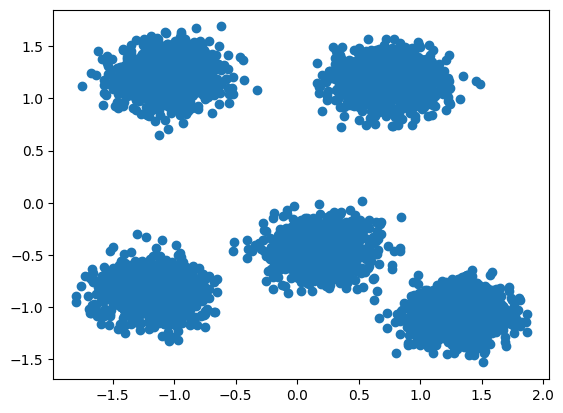

In [4]:
import matplotlib.pyplot as plt

plt.scatter(X_scaled[:, 0], X_scaled[:, 1])

kmeans = KMeans(n_clusters=5)
kmeans.fit(X_scaled)

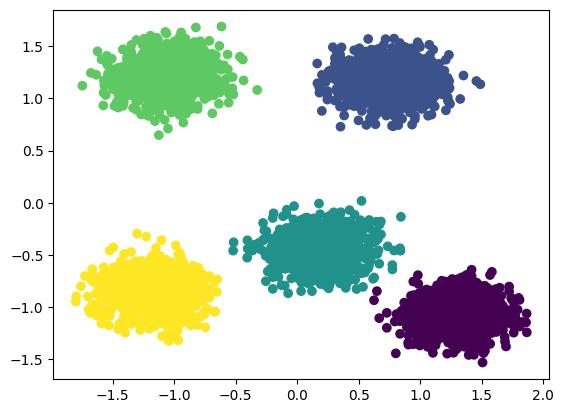

In [46]:
#plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans.labels_)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y)

In [47]:
from sklearn.datasets import make_moons

X, _ = make_moons(n_samples=5000, noise=0.05)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

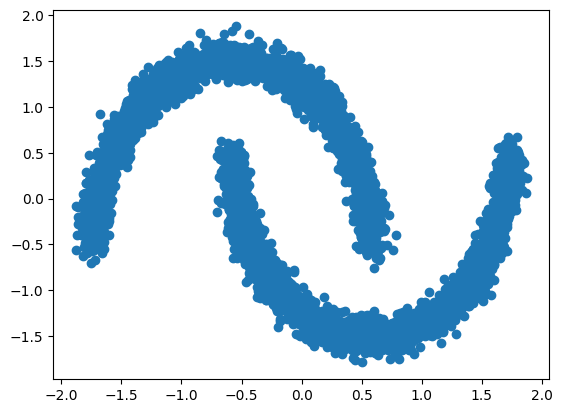

In [48]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1])

In [49]:
kmeans = KMeans(n_clusters=2)
kmeans.fit(X_scaled)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


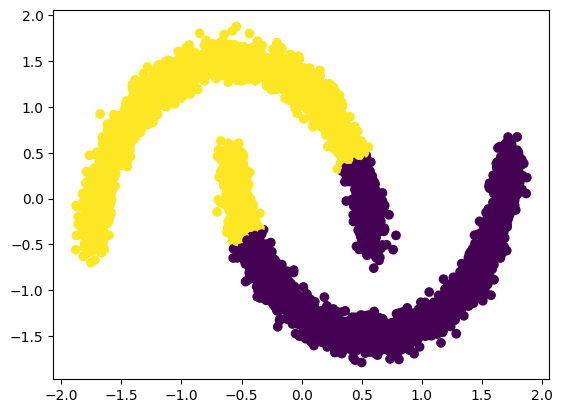

In [50]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans.labels_)

In [51]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.2)
dbscan.fit(X_scaled)

,eps,0.2
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


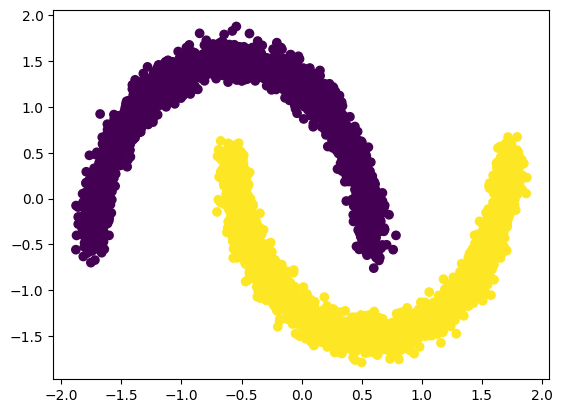

In [52]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=dbscan.labels_)

In [53]:
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [54]:
X, y = fetch_openml('mnist_784', return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [60]:
pca = PCA(n_components=20)

X_train_reduced = pca.fit_transform(X_train)
X_test_reduced = pca.transform(X_test)

In [56]:
X_train.shape

(56000, 784)

In [57]:
X_train_reduced.shape

(56000, 10)

In [ ]:
clf = LogisticRegression(max_iter=100)
clf.fit(X_train, y_train)

print(clf.score(X_test, y_test))

In [ ]:
clf = LogisticRegression(max_iter=100)
clf.fit(X_train_reduced, y_train)

print(clf.score(X_test_reduced, y_test))

In [62]:
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [63]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [64]:
clf = KNeighborsClassifier()
clf.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [65]:
clf.score(X_test_scaled, y_test)

0.9912280701754386

In [68]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = clf.predict(X_test_scaled)

In [69]:
accuracy_score(y_test, y_pred)

0.9912280701754386

In [70]:
precision_score(y_test, y_pred)

0.9868421052631579

In [71]:
recall_score(y_test, y_pred)

1.0

In [72]:
f1_score(y_test, y_pred)

0.9933774834437086

In [73]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [74]:
X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [75]:
reg = LinearRegression()
reg.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [76]:
reg.score(X_train_scaled, y_train)

0.6072584736119911

In [77]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

y_pred = reg.predict(X_test_scaled)

r2_score(y_test, y_pred)

0.5966302240226387

In [78]:
reg.score(X_test_scaled, y_test)

0.5966302240226387

In [79]:
mean_absolute_error(y_test, y_pred)

0.53517576484467

In [80]:
mean_squared_error(y_test, y_pred)

0.5426736063877824

In [ ]:
root_mean_squared_error(y_test, y_pred)

0.7366638354010481

In [89]:
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [83]:
X, y = load_breast_cancer(return_X_y=True)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [88]:
from sklearn.model_selection import cross_val_score

clf = KNeighborsClassifier()

scores = cross_val_score(clf, X_scaled, y, cv=5)

In [85]:
scores

array([0.96491228, 0.95614035, 0.98245614, 0.95614035, 0.96460177])

In [86]:
import numpy as np

np.mean(scores)

np.float64(0.9648501785437045)

In [90]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [91]:

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [92]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
}

In [93]:
from sklearn.model_selection import GridSearchCV

clf = RandomForestClassifier(n_jobs=-1)

grid = GridSearchCV(clf, param_grid, cv=3)

In [94]:
grid.fit(X_train, y_train)

,estimator,RandomForestC...ier(n_jobs=-1)
,param_grid,"{'max_depth': [None, 5, ...], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [95]:
grid.best_params_

{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}

In [96]:
best_clf = grid.best_estimator_

In [97]:
best_clf

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [98]:
best_clf.score(X_test, y_test)

0.972027972027972

In [99]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [100]:

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [102]:
from sklearn.pipeline import Pipeline

pipe = Pipeline ([
    ('scale', StandardScaler()),
    ('pca', PCA(n_components=10)),
    ('forest', RandomForestClassifier()),
])

pipe.fit(X_train, y_train)

,steps,"[('scale', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,10
,copy,True
,whiten,False
,svd_solver,'auto'


In [103]:
pipe.score(X_test, y_test)

0.8951048951048951